In [8]:
import sys
import time
import h5py
import torch
import math
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from utils import show_graph_loss, show_graph_model

# Data loading

In [9]:
# Connect torch to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [10]:
# Load test set
f = h5py.File('../data/sdr_wifi_test.hdf5', 'r')
X_test = f['X'][()]
y_test = f['y'][()]
f.close()

# Load train set
f = h5py.File('../data/sdr_wifi_train.hdf5', 'r')
X_train = f['X'][()]
y_train = f['y'][()]
f.close()

# Description of input variables

- `sequence_length` is the amount of IQ samples is in a single sample of data
- `nm_channels` is the amount of number each IQ samples consists of (2)
- `num_layers` is the amount of hidden layers that perform changes to get the correct prediction (chosen based on https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw)
- `output_size` is the amount of frequencies that are predicted, these are equal to the input since we want to see from the full prediction which frequency most likely has the lowest interference
- `num_epochs` is the amount of training rounds
- `learning_rate` is the rate at which the weights of the hidden layers are updated to improve prediction results (cannot be too high because it might overshoot)


In [11]:
data = torch.FloatTensor(X_train).to(device)
labels = torch.FloatTensor(y_train).to(device)

print(data.shape)
print(labels.shape)

# Neural network input
sequence_length = data.shape[1]
num_channels = data.shape[2]
num_layers = 1
output_size = labels.shape[1]

learning_rate = 1e-3
num_epochs = 20
batch_size = 128

torch.Size([1439971, 64, 2])
torch.Size([1439971, 4])


# Model definition

In [12]:
USE_LOGITS = True

In [13]:
class ConvModel(nn.Module):
    def __init__(self, sequence_length, num_channels, output_size):
        super(ConvModel, self).__init__()
        # First conv layer: from 2 channels (I/Q) to 16 channels
        self.conv1 = nn.Conv1d(in_channels=num_channels, out_channels=16, kernel_size=3, stride=1, padding=1)
        # Second conv layer: from 16 to 32 channels
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        
        # Pool to reduce dimensionality
        self.pool = nn.MaxPool1d(kernel_size=4, stride=4)
        
        # Final conv layer to get to 4 channels (one per wifi channel)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=4, kernel_size=3, stride=1, padding=1)
        
        # Global average pooling to get final predictions
        self.gap = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        # Step 1: get more information out of the IQ samples using convolution
        # Input shape: [batch, sequence_length, 2]
        x = x.permute(0, 2, 1)  # -> [batch, 2, sequence_length]
        
        # First conv + activation
        x = self.conv1(x)  # -> [batch, 16, sequence_length]
        x = torch.relu(x) # -> [batch, 16, sequence_length]
        x = self.pool(x)  # -> [batch, 16, sequence_length/4]
        
        # Second conv + activation
        x = self.conv2(x)  # -> [batch, 32, sequence_length/4]
        x = torch.relu(x) # -> [batch, 32, sequence_length/4]
        x = self.pool(x)  # -> [batch, 32, sequence_length/16]
        
        # Final conv to get channel predictions
        x = self.conv3(x)  # -> [batch, 4, sequence_length/16]
        
        # Global average pooling to get one prediction per channel
        x = self.gap(x)  # -> [batch, 4, 1]
        x = x.squeeze(-1)  # -> [batch, 4]
        
        if not USE_LOGITS:
            x = torch.sigmoid(x)
        return x

# Initialize model and training parameters
model = ConvModel(
    sequence_length=sequence_length,
    num_channels=num_channels,
    output_size=output_size
).to(device)
criterion = nn.BCEWithLogitsLoss() if USE_LOGITS else nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Training

In [14]:
dataset = TensorDataset(data, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

avg_loss_history = []
avg_loss = 0

min_loss_history = []
max_loss_history = []

start_time = time.time()

# Training loop
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    min_loss = 10
    max_loss = 0

    for i, (x_batch, y_batch) in enumerate(train_loader):
        # Forward pass
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        current_loss = loss.item()
        total_loss += current_loss
        min_loss = min(min_loss, current_loss)
        max_loss = max(max_loss, current_loss)

        sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}] | ({i} / {math.floor(len(data) / batch_size)}) | Loss: {loss.item():.4f} | Avg Loss last epoch: {avg_loss:.4f}")

    avg_loss = total_loss / len(train_loader)
    avg_loss_history.append(avg_loss)
    min_loss_history.append(min_loss)
    max_loss_history.append(max_loss)

    # Step the scheduler
    scheduler.step()

end_time = time.time()

training_time = end_time - start_time

Epoch [20/20] | (11249 / 11249) | Loss: 0.1271 | Avg Loss last epoch: 0.1395

# Testing

In [15]:
model.eval()
with torch.no_grad():
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    for i in range(0, len(X_test), batch_size):
        X_batch = torch.FloatTensor(X_test[i:i+batch_size]).to(device)
        y_batch = torch.FloatTensor(y_test[i:i+batch_size]).to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        total_loss += loss.item()

        # Convert probabilities to binary predictions
        predicted = (outputs > 0).float()

        # Calculate the number of correct predictions
        correct_predictions += (predicted == y_batch).sum().item()
        total_samples += y_batch.numel()

        sys.stdout.write(f"\rTest Loss: {loss.item():.4f}")

    accuracy = correct_predictions / total_samples
    print(f"\nTotal Test Loss: {total_loss}")
    print(f"Test Accuracy: {accuracy:.4f}")

print("\nDone!")

Test Loss: 0.1462
Total Test Loss: 172.46239475905895
Test Accuracy: 0.9488

Done!


# Documentation

In [16]:
import pandas as pd

# Make a prediction based on the last sample
model.eval()

results = []

with torch.no_grad():
    for i in range(100):
        X_sample = torch.FloatTensor(X_test[i]).to(device)
        
        # Change shape from (256, 2) to (1, 256, 2)
        X_sample = X_sample.unsqueeze(0)

        time_start = time.time()

        output = model(X_sample)

        time_end = time.time()

        predicted = (output > 0).float()
        results.append({
            'index': i,
            'predicted': predicted.tolist()[0],
            'actual': y_test[i].tolist(),
            'output': output,
            'time': (time_end - time_start) * 1000,
            'total_accuracy': accuracy
        })

results_df = pd.DataFrame(results)
results_df.to_csv('../docs/results/conv/conv_tests.csv', index=False)

In [17]:
accuracy_df = pd.read_csv('../docs/results/accuracy.csv')

# Remove results of current model with same sequence length
accuracy_df = accuracy_df[(accuracy_df['model'] != 'conv') | (accuracy_df['sequence_length'] != data.shape[1]) | (accuracy_df['sampling_rate'] != 1)]
accuracy_df = pd.concat([accuracy_df, pd.DataFrame([{
    'model': 'conv',
    'label': 'Convolutional model',
    'accuracy': accuracy * 100,
    'training_time': training_time,
    'epochs': num_epochs,
    'avg_response_time': results_df['time'].mean(),
    'avg_loss': avg_loss,
    'min_loss': min_loss,
    'max_loss': max_loss,
    'sequence_length': data.shape[1],
    'sampling_rate': 1
}])])
accuracy_df.to_csv('../docs/results/accuracy.csv', index=False)

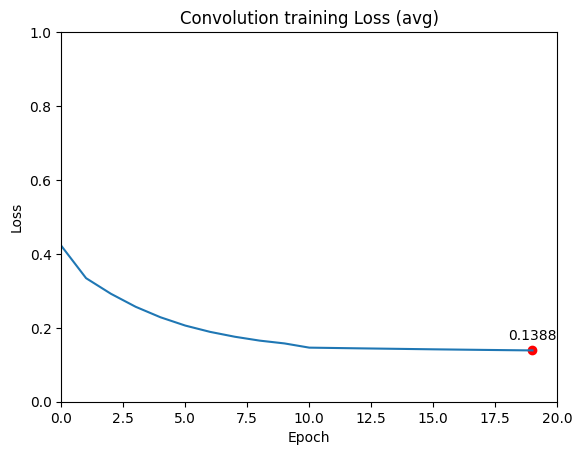

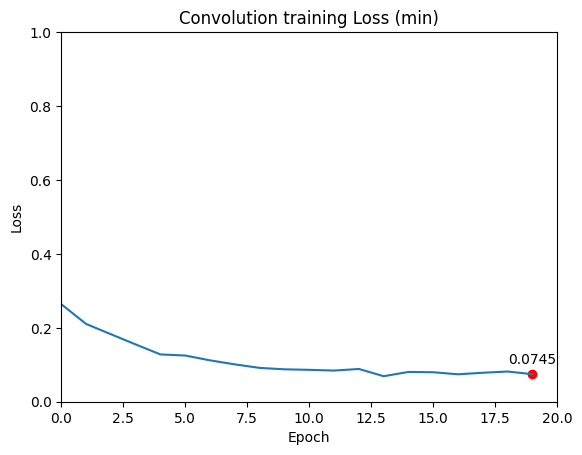

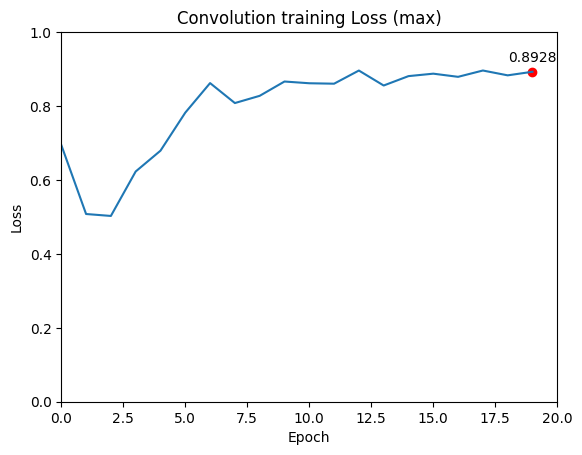

In [18]:
show_graph_loss(plot_label="Convolution", loss_history=avg_loss_history, num_epochs=num_epochs, label='avg', filename='../docs/results/conv/conv_avg_loss.png')
show_graph_loss(plot_label="Convolution", loss_history=min_loss_history, num_epochs=num_epochs, label='min', filename='../docs/results/conv/conv_min_loss.png')
show_graph_loss(plot_label="Convolution", loss_history=max_loss_history, num_epochs=num_epochs, label='max', filename='../docs/results/conv/conv_max_loss.png')
show_graph_model(model=model, test_data=X_test[0], device=device, filename='../docs/results/conv/conv_model')

In [19]:
# Save model
torch.save(model.state_dict(), '../models/conv.pth')